In [ ]:
import os

# Working directory must contain AlphaSimPy.py for imports
os.chdir(r"/Users/mtwatson/Library/CloudStorage/Box-Box/Projects/AI agent for breeding/Endpoint 2 agent")


# Batista Breeding Program - AlphaSimPy Notebook

This notebook converts the provided BRAID breeding program abstraction into a tutorial-style AlphaSimPy workflow.

The BRAID program describes:
- a **parent** population,
- crossing to create an **F1 population**,
- phenotypic selection on **T1** to create **Stage 1** candidates,
- two parent recycling paths:
  - a **Stage 1 -> Parents** path approximating independent culling using **T2** and **index_trait**,
  - an **F1 -> Parents** path using **index_trait**,
- merging recycled parents back into the parent pool.

**Authors**: Generated from BRAID abstraction  
**Date**: 2026  
**Package**: AlphaSimPy


## BRAID-Derived Assumptions

The BRAID abstraction contains several placeholders or unspecified values. To make the notebook executable, the following explicit assumptions are used:

1. **Genome size placeholders**  
   The BRAID file lists `chromosomes: 0` and `n_qtl: 0`, which are not executable.  
   This notebook assumes:
   - `nChr = 5`
   - `nQtlPerChr = 200`
   - `nSnpPerChr = 0`

2. **Trait model**  
   The BRAID file defines three additive traits: `T1`, `T2`, and `index_trait`, each with heritability 0.3.  
   This notebook implements three additive traits with moderate genetic variance and uses phenotyping error chosen to roughly reflect moderate heritability.

3. **Crossing design**  
   The BRAID file specifies a custom crossing scheme but does not define `n_crosses`.  
   Since the F1 population size is 5000, this notebook uses:
   - `nCrosses = 250`
   - `nProgeny = 20`
   so that `250 x 20 = 5000` F1 individuals.

4. **Stage 1 size**  
   The BRAID workflow selects 500 individuals from F1 into Stage 1. This is implemented directly.

5. **Independent culling approximation**  
   AlphaSimPy does not provide a direct "independent culling" helper in the same simple form as truncation selection.  
   This notebook approximates independent culling by:
   - phenotyping Stage 1 candidates for `T2` and `index_trait`,
   - retaining individuals above median thresholds for both traits,
   - selecting the top 50 among retained individuals using the sum of standardized phenotypes.

6. **One recurrent cycle**  
   The BRAID horizon is 1 cycle, so the notebook simulates one cycle and reports summary statistics before and after recycling.


## Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from AlphaSimPy import runMacs, SimParam, newPop, randCross, setPheno, selectInd, meanG, varG, mergePops

print("AlphaSimPy Batista BRAID Tutorial")
print("Libraries imported successfully.")

AlphaSimPy Batista BRAID Tutorial
Libraries imported successfully.


## Global Parameters

Set up executable simulation parameters derived from the BRAID abstraction and the assumptions listed above.


In [3]:
# BRAID-derived population sizes
nParents = 50
nF1 = 5000
nStage1 = 500
nRecycleIC = 50
nRecycleIndex = 50

# Executable assumptions for genome architecture
nChr = 5
nQtlPerChr = 200
nSnpPerChr = 0

# Trait assumptions
traitNames = ["T1", "T2", "index_trait"]
nTraits = len(traitNames)
traitMean = [0.0, 0.0, 0.0]
traitVar = [1.0, 1.0, 1.0]

# Phenotyping error variance chosen to represent moderate heritability
varE = [2.333, 2.333, 2.333]

# Crossing design chosen to match F1 size
nCrosses = 250
nProgeny = 20

# Recurrent cycle count from BRAID horizon
nCycles = 1

print("Simulation parameters")
print(f"  Parents: {nParents}")
print(f"  F1 size: {nF1}")
print(f"  Stage 1 selected: {nStage1}")
print(f"  Recycled parents from Stage 1 path: {nRecycleIC}")
print(f"  Recycled parents from F1 index path: {nRecycleIndex}")
print(f"  Chromosomes: {nChr}")
print(f"  QTL per chromosome: {nQtlPerChr}")
print(f"  Traits: {traitNames}")
print(f"  Crosses: {nCrosses}")
print(f"  Progeny per cross: {nProgeny}")


Simulation parameters
  Parents: 50
  F1 size: 5000
  Stage 1 selected: 500
  Recycled parents from Stage 1 path: 50
  Recycled parents from F1 index path: 50
  Chromosomes: 5
  QTL per chromosome: 200
  Traits: ['T1', 'T2', 'index_trait']
  Crosses: 250
  Progeny per cross: 20


## Create Founders and Simulation Parameters

Generate founder haplotypes, define three additive traits, and create the initial parent population.


In [4]:
print("Creating founder population...")

founderPop = runMacs(
    nInd=nParents,
    nChr=nChr,
    segSites=nQtlPerChr + nSnpPerChr,
    inbred=True,
    species="GENERIC"
)

print(f"Founder population created: {founderPop.n_ind} individuals")

SP = SimParam(founderPop)

# Add three additive traits corresponding to T1, T2, and index_trait
SP.addTraitAG(nQtlPerChr=nQtlPerChr, mean=traitMean[0], var=traitVar[0])
SP.addTraitAG(nQtlPerChr=nQtlPerChr, mean=traitMean[1], var=traitVar[1])
SP.addTraitAG(nQtlPerChr=nQtlPerChr, mean=traitMean[2], var=traitVar[2])

SP.setTrackPed(True)

parents = newPop(founderPop, simParam=SP)

print(f"Number of traits in simulation: {SP.n_traits}")
print(f"Initial parent population size: {parents.n_ind}")
print("Initial parent mean genetic values:", meanG(parents))
print("Initial parent genetic variances:", varG(parents))


Creating founder population...
Founder population created: 50 individuals
Number of traits in simulation: 3
Initial parent population size: 50
Initial parent mean genetic values: [ 2.48689958e-16 -9.76996262e-17 -3.17523785e-16]
Initial parent genetic variances: [1. 1. 1.]


## Helper Functions

These helper functions keep the notebook readable and implement the BRAID-specific recycling logic.


In [5]:
def getPhenoMatrix(pop):
    """Return phenotype matrix as a NumPy array."""
    return np.array(pop.pheno)

def summarizePop(pop, label):
    mg = np.array(meanG(pop))
    vg = np.array(varG(pop))
    rows = []
    for i, trait in enumerate(traitNames):
        rows.append({
            "population": label,
            "trait": trait,
            "meanG": float(mg[i]),
            "varG": float(vg[i])
        })
    return pd.DataFrame(rows)

def subsetPopByIndices(pop, indices):
    """Create a subset population using integer indices."""
    from AlphaSimPy import Pop
    indices = list(indices)
    return Pop(
        n_ind=len(indices),
        n_chr=pop.n_chr,
        ploidy=pop.ploidy,
        n_loci=pop.n_loci,
        geno=[pop.geno[chrIdx][:, :, indices] for chrIdx in range(pop.n_chr)],
        gen_map=pop.gen_map,
        centromere=pop.centromere,
        inbred=pop.inbred,
        id=[pop.id[i] for i in indices],
        iid=[pop.iid[i] for i in indices],
        mother=[pop.mother[i] for i in indices],
        father=[pop.father[i] for i in indices],
        sex=[pop.sex[i] for i in indices],
        n_traits=pop.n_traits,
        gv=pop.gv[indices, :],
        pheno=pop.pheno[indices, :],
        ebv=pop.ebv[indices, :] if hasattr(pop, "ebv") and pop.ebv is not None and len(pop.ebv) > 0 else np.empty((len(indices), 0)),
        gxe=pop.gxe,
        fix_eff=[pop.fix_eff[i] for i in indices] if hasattr(pop, "fix_eff") and len(pop.fix_eff) == pop.n_ind else [],
        misc=pop.misc,
        misc_pop=pop.misc_pop
    )

def independentCullingRecycle(stage1Pop, nSelect=50):
    """Approximate independent culling on T2 and index_trait phenotypes."""
    pheno = getPhenoMatrix(stage1Pop)
    t2 = pheno[:, 1]
    idx = pheno[:, 2]

    t2Threshold = np.median(t2)
    idxThreshold = np.median(idx)

    keep = np.where((t2 >= t2Threshold) & (idx >= idxThreshold))[0]

    if len(keep) < nSelect:
        # Fallback: rank all individuals by standardized T2 + index_trait
        zT2 = (t2 - np.mean(t2)) / np.std(t2)
        zIdx = (idx - np.mean(idx)) / np.std(idx)
        score = zT2 + zIdx
        keep = np.argsort(score)[::-1][:nSelect]
    else:
        zT2 = (t2[keep] - np.mean(t2[keep])) / np.std(t2[keep])
        zIdx = (idx[keep] - np.mean(idx[keep])) / np.std(idx[keep])
        score = zT2 + zIdx
        keep = keep[np.argsort(score)[::-1][:nSelect]]

    return subsetPopByIndices(stage1Pop, keep)


## Run One BRAID Recurrent Cycle

This section implements the directed graph in the BRAID workflow:

1. `parents -> f1_population` by crossing  
2. `f1_population -> stage1_candidates` by phenotypic selection on `T1`  
3. `stage1_candidates -> parent_recycle_ic` by approximate independent culling on `T2` and `index_trait`  
4. `f1_population -> parent_recycle_index` by index-based selection on `index_trait`  
5. merge recycled parents back into `parents`


In [6]:
cycleSummaries = []

cycleSummaries.append(summarizePop(parents, "parents_start"))

print("Running recurrent cycle 1")

# 1. Cross parents to create F1
f1Population = randCross(parents, nCrosses=nCrosses, nProgeny=nProgeny, simParam=SP)
print(f"F1 population size: {f1Population.n_ind}")

# 2. Phenotype F1 and select top individuals on T1 into Stage 1
f1Population = setPheno(f1Population, varE=varE, simParam=SP)
stage1Candidates = selectInd(f1Population, nInd=nStage1, trait=1, use="pheno", simParam=SP)
stage1Candidates = setPheno(stage1Candidates, varE=varE, simParam=SP)
print(f"Stage 1 candidate size: {stage1Candidates.n_ind}")

# 3. Recycle Stage 1 to parents using approximate independent culling on T2 and index_trait
parentRecycleIC = independentCullingRecycle(stage1Candidates, nSelect=nRecycleIC)
print(f"Recycled parents from Stage 1 IC path: {parentRecycleIC.n_ind}")

# 4. Recycle F1 directly to parents using index_trait
parentRecycleIndex = selectInd(f1Population, nInd=nRecycleIndex, trait=3, use="pheno", simParam=SP)
print(f"Recycled parents from F1 index path: {parentRecycleIndex.n_ind}")

# 5. Merge recycled parents back into a refreshed parent pool
mergedParents = mergePops([parentRecycleIC, parentRecycleIndex])
mergedParents = setPheno(mergedParents, varE=varE, simParam=SP)

# Keep parent pool size at 50 using index_trait as the recycling objective
parents = selectInd(mergedParents, nInd=nParents, trait=3, use="pheno", simParam=SP)
print(f"Refreshed parent pool size: {parents.n_ind}")

cycleSummaries.append(summarizePop(f1Population, "f1_population"))
cycleSummaries.append(summarizePop(stage1Candidates, "stage1_candidates"))
cycleSummaries.append(summarizePop(parentRecycleIC, "parent_recycle_ic"))
cycleSummaries.append(summarizePop(parentRecycleIndex, "parent_recycle_index"))
cycleSummaries.append(summarizePop(parents, "parents_end"))

summaryDf = pd.concat(cycleSummaries, ignore_index=True)
summaryDf


Running recurrent cycle 1
F1 population size: 5000
Stage 1 candidate size: 500
Recycled parents from Stage 1 IC path: 50
Recycled parents from F1 index path: 50
Refreshed parent pool size: 50


,population,trait,meanG,varG
0,parents_start,T1,2.486900e-16,1.000000
1,parents_start,T2,-9.769963e-17,1.000000
2,parents_start,index_trait,-3.175238e-16,1.000000
3,f1_population,T1,-8.074761e-02,1.147263
4,f1_population,T2,-6.944928e-02,1.058056
5,f1_population,index_trait,-7.338828e-03,0.931838
6,stage1_candidates,T1,9.620721e-01,0.843970
7,stage1_candidates,T2,-8.334046e-02,1.088667
8,stage1_candidates,index_trait,9.760208e-02,0.802959
9,parent_recycle_ic,T1,1.176579e+00,0.514554


## Summarize Tracked Outputs

The BRAID abstraction requests tracking of:
- genetic mean
- genetic variance
- inbreeding

This notebook directly summarizes genetic mean and genetic variance.  
Inbreeding tracking is noted as requested by BRAID, but a simple direct inbreeding summary is not added here because the exact AlphaSimPy helper for inbreeding may vary by installation. Pedigree tracking is enabled so this can be extended if needed.


Population summary by stage
              population        trait         meanG      varG
0          parents_start           T1  2.486900e-16  1.000000
1          parents_start           T2 -9.769963e-17  1.000000
2          parents_start  index_trait -3.175238e-16  1.000000
3          f1_population           T1 -8.074761e-02  1.147263
4          f1_population           T2 -6.944928e-02  1.058056
5          f1_population  index_trait -7.338828e-03  0.931838
6      stage1_candidates           T1  9.620721e-01  0.843970
7      stage1_candidates           T2 -8.334046e-02  1.088667
8      stage1_candidates  index_trait  9.760208e-02  0.802959
9      parent_recycle_ic           T1  1.176579e+00  0.514554
10     parent_recycle_ic           T2  6.805016e-01  0.944151
11     parent_recycle_ic  index_trait  5.969390e-01  0.652177
12  parent_recycle_index           T1 -2.710526e-01  1.114723
13  parent_recycle_index           T2 -3.726638e-02  1.283227
14  parent_recycle_index  index_trait  1.1

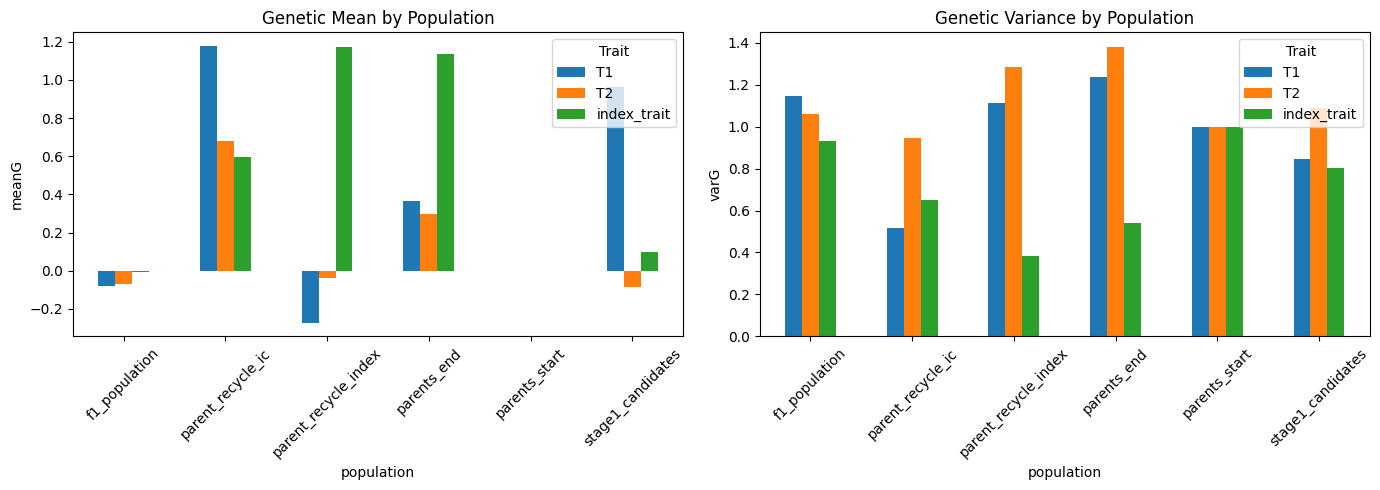

In [7]:
print("Population summary by stage")
print(summaryDf)

pivotMean = summaryDf.pivot(index="population", columns="trait", values="meanG")
pivotVar = summaryDf.pivot(index="population", columns="trait", values="varG")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivotMean.plot(kind="bar", ax=axes[0])
axes[0].set_title("Genetic Mean by Population")
axes[0].set_ylabel("meanG")
axes[0].legend(title="Trait")
axes[0].tick_params(axis="x", rotation=45)

pivotVar.plot(kind="bar", ax=axes[1])
axes[1].set_title("Genetic Variance by Population")
axes[1].set_ylabel("varG")
axes[1].legend(title="Trait")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## Interpretation

This executable AlphaSimPy notebook is a faithful operationalization of the Batista BRAID abstraction with explicit assumptions where the source diagram omitted executable details.

Key correspondences to the BRAID program:
- **Parents** are initialized from 50 founders.
- **F1 Population** is generated by random crossing to size 5000.
- **Stage 1** is formed by selecting 500 individuals on **T1 phenotype**.
- **Parent recycle IC** is approximated from Stage 1 using **T2** and **index_trait**.
- **Parent recycle index** is selected directly from F1 using **index_trait**.
- The two recycled parent sets are merged and reduced back to a parent pool of 50.

If more detailed BRAID information becomes available, the notebook can be refined further by:
- replacing assumed genome parameters,
- implementing the exact crossing design,
- using a more formal independent culling rule,
- extending from one cycle to multiple recurrent cycles.
